# PINN-Slicer: Figure & Table Reproduction

This notebook reproduces the figures and tables in "PINN-Slicer: Exploiting Rotational Symmetry to Solve the Photon Orbit Equation around a Black Hole"
(submitted to ML4PS 2026).

Note: Figures 1 and 5 (schematics) were created outside this notebook
and are not reproduced here.

Commit at submission: ______TODO______

## Setup

### Fetch GitHub repository
**TODO**: change with anonymous github

In [1]:
import os

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    if not os.path.exists('pinn4bhoc'):
        !git clone -q https://github.com/soot-bit/pinn4bhoc.git
    !cd pinn4bhoc && pip install .

Processing /content/pinn4bhoc
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for pinn4bhoc: filename=pinn4bhoc-0.1.0-py3-none-any.whl size=16366 sha256=fdfca0cc36ff7dd4fa8537744b15650510f6fbaae267d4b833c7ee22fab19031
  Stored in directory: /tmp/pip-ephem-wheel-cache-lqb6jfxc/wheels/b5/5f/9f/69d3b98f246de8d5ccd5e25808f70e37f0d01b823c89b1e75f
Successfully built pinn4bhoc
  Attempting uninstall: pinn4bhoc
    Found existing installation: pinn4bhoc 0.1.0
    Uninstalling pinn4bhoc-0.1.0:
      Successfully uninstalled pinn4bhoc-0.1.0


### Imports

In [2]:
import numpy as np
import math
import matplotlib as mp
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

# --- project module pinn4bhoc ---
# Neural net architecture
import pinn4bhoc.nn as mlp

# Conversion: initial condition (r, delta) → (u0, v0)
from pinn4bhoc.orbits.orbit_setup import compute_u0_v0

# Boomerang orbit parameters
from pinn4bhoc.orbits.orbit_setup import INIT_COND, U0, V0, COLOR

### Constants

In [3]:
# --- Device ---
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Available device: {str(DEVICE):4s}')

# --- Output folder ---
FIG_DIR = 'figures'
os.makedirs(FIG_DIR, exist_ok=True)

# --- Trained model checkpoints, keyed by dphi ---
MODEL_RUNS = {
    0.05: 'pinn4bhoc/runs/dphi005/dphi005_params.pth',
    0.10: 'pinn4bhoc/runs/dphi010/dphi010_params.pth',
    0.20: 'pinn4bhoc/runs/dphi020/dphi020_params.pth',
    0.40: 'pinn4bhoc/runs/dphi040/dphi040_params.pth',
    0.80: 'pinn4bhoc/runs/dphi080/dphi080_params.pth',
    1.60: 'pinn4bhoc/runs/dphi160/dphi160_params.pth',
    5*np.pi/2: 'pinn4bhoc/runs/five_pi_by_2/pinn_params.pth',
}

# --- Orbit color palette ---
CRIMSON      = '#A00020'  # dark red           — inner spiralling orbit
GOLDENROD    = '#E5A400'  # golden yellow      - photon sphere
ORANGE       = '#D2451E'  # burnt orange       - spiral in
YELLOW_GREEN = '#4C9A2A'  # yellow-green       - boomerang
COBALT       = '#1F5FA8'  # clean mid-blue     - deflected, u-turn


# --- Orbit sets ---
def make_orbits(orbits_rd):
    """Expand (r0, delta) orbit specs into full dicts with (u0, v0)."""
    orbits = []
    for o in orbits_rd:
        u0, v0 = compute_u0_v0(o['r0'], o['delta'])
        orbits.append(dict(u0=u0, v0=v0, **o))
    return orbits

# For PINN + FD comparison: photon sphere, spiral-in, boomerang, near u-turn
DEMO_ORBITS = make_orbits([
    dict(r0=1.5, delta=90,       color=GOLDENROD),    # photon sphere (v0=0)
    dict(r0=3.5, delta=38.82,    color=ORANGE),       # spirals in
    dict(r0=5.0, delta=27.99369, color=YELLOW_GREEN), # boomerang
    dict(r0=6.5, delta=22.50,    color=COBALT),       # near u-turn, escapes
])

# For failure illustration
BOOMERANG_ORBITS = []
for a, u0, v0, color in zip(INIT_COND, U0, V0, COLOR):
    r0, delta = a
    orbit = {'u0': u0, 'v0': v0, 'r0': r0, 'delta': delta, 'color': color}
    BOOMERANG_ORBITS.append(orbit)

Available device: cpu 


### Solvers

#### ↳ Finite Difference (FD) solver

We roughly follow the semantics of the ordinary differential equation (ODE) solver $\texttt{scipy.integrate.odeint}(func, y0, t, \cdots)$, which in addition to
the initial conditions $y0$, requires the user to provide an array $t$ (called $\texttt{phi}$ here) that specifies the sequence of points at which the solution is to be returned. (Note, the user supplied sequence of points, $t$, may differ from the internal sequence that is used to compute an accurate finite-difference solution of the ODE.) Since our custom solver is designed specifically for the ODE
\begin{align}
    \ddot{u} & = G(u),\quad
    G(u) = \frac{3u^2}{2} - u,
\end{align}
the $func$ argument is not needed. As in $\texttt{scipy.integrate.odeint}$, the above 2nd-order ODE
is coded within the custom solver as two coupled 1st order equations
\begin{align}
    D u & = v,\\
    D v & = G,
\end{align}
where $D$ is the derivative operator, $d/d\phi$.

Using $x$ as the name for the angular variable (to distinguish it from the user-supplied array $\texttt{phi}$), the solution at $u(x+h)$ can be computed using the Taylor series expansion:
\begin{align}
    u(x+h) & = u + Du \, h + \frac{D^2 u \, h^2}{2!} + \frac{D^3 u \, h^3}{3!} + \frac{D^4 u \, h^4}{4!} + O(h^5), \\
        & = u + v \, h + \frac{G \, h^2}{2} + \frac{DG \, h^3}{6} + \frac{D^2 G \, h^4}{24} + O(h^5).
\end{align}
<br>
Applying the operator $D$ to $u(x + h)$ yields
\begin{align}
    v(x+h) & = v + G \, h + \frac{DG \, h^2}{2} + \frac{D^2 G \, h^3}{6} + \frac{D^3 G \, h^4}{24} + O(h^5).
\end{align}
<br>
Because of the simplicity of the function $G(u) = 3 u^2 / 2 - u$, the
quantities $DG$, $D^2G$, and $D^3G$ are readily computed:
\begin{align}
    DG & = D \left[ \frac{3 u^2}{2} - u \right], \nonumber\\
            & = 3 u Du - Du,\nonumber\\
            & = Q v, \quad\text{ where } Q \equiv 3 u - 1,\\
            \nonumber\\
    D^2G & = (D Q) v + Q (D v), \\
         & = 3 v^2 + Q G,\\ \nonumber\\
    D^3G & = (9 G + Q^2) v .
\end{align}
We thus arrive at explicit formulae for $u(x+h)$ and $v(x+h)$ that depend solely on the known quantities $u(x)$, $v(x)$, and $G(x)$. The solution is arrived at through iterative application of these formulae. This is what is done in the class $\texttt{DFPhotonOrbitSolver}$, where, without loss of generality, it is assumed that the orbit always starts at $\phi=0$.

In [4]:
class FDPhotonOrbitSolver:
    '''
    h = np.pi / 10000

    We write the 2nd order photon orbit equation

    D^2 u = G(u), with G(u) = 1.5*u**2 - u

    as two 1st order equations

    Du = v
    Dv = G

    where D is the derivative operator.
    '''
    def __init__(self, h=np.pi/10_000, K=1_000_000, phi_max_guard=10*np.pi):
        self.h = h                       # step size
        self.K = K                       # maximum number of steps
        self.phi_max_guard = phi_max_guard  # safety cap if no boundary is hit

    def __call__(self, y0, phi):
        '''
        y0:  initial conditions (u0, v0)
             u0 = u(0)
             v0 = Du(0)

        phi: numpy array of points at which the solution should be returned.
             phi[-1] sets the requested upper limit of the orbit.
        '''
        try:
            u0, v0 = y0[0, :]
        except (IndexError, TypeError):
            u0, v0 = y0

        umin = 0.0  # r = 1/u = infinity
        umax = 1.0  # r = 1/u = Schwarzschild radius

        K             = self.K
        phi_max_guard = self.phi_max_guard
        phi_max_user  = phi[-1]

        h1 = self.h
        h2 = h1*self.h
        h3 = h2*self.h
        h4 = h3*self.h

        x = [0]
        u = [u0]
        v = [v0]

        for i in range(1, K):

            Q  = 3*u0 - 1

            G0 = 1.5 * u0**2 - u0
            G1 = Q*v0
            G2 = 3*v0**2 + Q*G0
            G3 = (9*G0 + Q**2) * v0

            # compute u(x+h)
            u1 = u0 + v0*h1 + G0*h2/2 + G1*h3/6 + G2*h4/24

            # compute v(x+h)
            v1 = v0 + G0*h1 + G1*h2/2 + G2*h3/6 + G3*h4/24

            if u1 < umin: break               # escaped to infinity
            if u1 > umax: break               # absorbed at event horizon
            if x[-1] > phi_max_user: break    # reached user-requested phi
            if x[-1] > phi_max_guard: break   # safety cap

            # accumulate solution
            x.append(i*h1)
            u.append(u1)
            v.append(v1)

            # apply recursion
            u0 = u1
            v0 = v1

        xa = np.array(x)
        ua = np.array(u)
        va = np.array(v)

        # Actual extent of the computed orbit (boundary, user limit, or guard)
        phi_max_orbit = xa[-1]

        # Return only the requested points that fall within what was computed
        select = phi < phi_max_orbit
        phi_out = phi[select]

        u_out = np.interp(phi_out, xa, ua)
        v_out = np.interp(phi_out, xa, va)

        return u_out, v_out, phi_out

#### ↳ Model loading


In [5]:
def load_pinn(path):
    print(f'\nLoading PINN model from parameter file: {path}\n')
    net  = mlp.FCNN().to(DEVICE)
    pinn = mlp.Solution(net).to(DEVICE)
    pinn.load(path)
    return pinn

#### ↳ PINN Solver

In [6]:
def pinn_solver(pinn, y0, phi, dphi,
                device=torch.device(
                    'cuda' if torch.cuda.is_available() else 'cpu'),
                debug=False):
    '''
    pinn         The PINN
    y0:          (u0, v0) initial conditions
    phi:         phi values at which to return solution
    dphi:        phi segment
    device:      Computational device.
    '''

    # Notes:
    # 1. The default types in PyTorch are float32 and int64.
    # 2. torch.tensor inherits the fundamental type of its argument.
    # 3. torch.Tensor uses the current default PyTorch type (float32).

    # We need to compute the PINN at the points in the array phi.
    # However, to do so we need also to compute the PINN at the
    # boundary points x_i = (i+1)*DPHI, i = 0, 1, 2, ... because
    # the (u_i, v_i) pair at each of these points are the initial
    # conditions for segment i.

    # 1. Find into which phi segment the specified phi values land
    segments  = (phi / dphi).astype(int)
    nsegments = segments[-1] + 1 # number of phi segments
    if debug:
        print(f'segments:     {segments[:15]}...{segments[-4:-1]}')

    # 2. Compute phi values modulo dphi; convert phi to PyTorch default float type
    phi_mod_dphis = (phi - segments * dphi).astype(np.float32)
    if debug:
        print(f'phi mod dphi: {phi_mod_dphis[:12]}...')

    # 3. Get segment boundary markers: markers[i] = segments[i+1] - segments[i]
    markers = np.diff(segments)
    if debug:
        print(f'markers:      {markers[:15]}...{markers[-4:-1]}')

    # 4. Find 1 + ordinal values of boundary markers, that is, the places
    #    (plus 1) at which we need to chop up phi_mod_dphis
    cuts = np.flatnonzero(markers) + 1
    if debug:
        print(f'cuts:         {cuts[:15]}...{cuts[-4:-1]}')

    # 5. Convert to tensors
    phi_mod_dphis = torch.tensor(phi_mod_dphis).view(-1, 1)
    cuts_t = torch.tensor(cuts)
    dphi_t = phi_mod_dphis.new_tensor([dphi]).view(-1, 1)

    # 6. Change type of y0 to float32 to be consistent with PyTorch default
    try:
        y0 = [y.astype(np.float32) for y in y0]
    except:
        y0 = np.asarray(y0, dtype=np.float32)

    # -------------------------------------------------------------
    # Apply the PINN recursively
    # -------------------------------------------------------------
    U = []
    V = []
    for p in torch.tensor_split(phi_mod_dphis, cuts_t):

        # For the phi (mod dphi) values of the current segment,
        # inject a point at phi = DPHI
        phi_t = torch.cat([p, dphi_t]).requires_grad_(True)

        # Initial conditions
        y0 = torch.tensor(y0).detach().to(device)

        # Compute PINN solution at every point of segment
        u = pinn(phi_t, y0)      # u(phi)
        v = pinn.diff(u, phi_t)  # v(phi) = du/dphi

        # Squeeze away extraneous dimension
        u = u.squeeze()          # shape: (-1, 1) => (-1, )
        v = v.squeeze()

        # Check if we've reached infinity or the event horizon
        spacetime_boundary_reached = ((u < 0) + (u > 1)).any()

        if spacetime_boundary_reached:
            u = torch.where(u < 0, 1e-10, u) # Impose boundary at "infinity"
            u = torch.where(u > 1, 1, u)     # Impose boundary at event horizon
            v = pinn.diff(u.view(-1, 1), phi_t).squeeze()   # Update v(phi)

        # Concatenate orbital segments, but drop injected point
        U.append(u[:-1])
        V.append(v[:-1])

        if spacetime_boundary_reached:
            break

        # -------------------------------------------------------------
        # Spacetime boundary not reached, so apply recursion.
        # -------------------------------------------------------------
        # The right boundary values of the current phi segment become
        # the initial conditions y0 for the next phi segment. This is
        # why a right boundary point is injected into each phi segment.
        u0 = u[-1]
        v0 = v[-1]

        y0 = np.array([u0.detach().cpu().item(), v0.detach().cpu().item()], dtype=np.float32)

    # Detach from computation tree, send to CPU, and convert to numpy array.
    u = torch.cat(U).detach().cpu().numpy()
    v = torch.cat(V).detach().cpu().numpy()

    return u, v

### Plotting

In [9]:
# ═══════════════════════════════════════════════════════════════
# Plotting
#
# Classes:
#   OrbitPlotXY    — Cartesian (x, y) in units of r_s
#   OrbitPlotUPhi  — (phi, u) with u = r_s / r
#
# Both take an existing matplotlib `ax`.
# Can be used standalone.
#
# Function:
#   plot_xy_uphi() —  Builds the paired figure.
# ═══════════════════════════════════════════════════════════════

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.lines as mlines


mpl.rcParams.update({
    'font.family':         'serif',
    'mathtext.fontset':    'stix',
    'font.size':           11,
    'axes.linewidth':      0.8,
    'xtick.direction':     'in',
    'ytick.direction':     'in',
    'xtick.major.size':    4,
    'ytick.major.size':    4,
    'xtick.minor.size':    2,
    'ytick.minor.size':    2,
    'xtick.top':           True,
    'ytick.right':         True,
    'grid.color':          '#e0e0e0',
    'grid.linewidth':      0.5,
    'legend.frameon':      False,
    'legend.fontsize':     11,
    'legend.labelspacing': 0.8,
    'figure.dpi':          150,
    'savefig.dpi':         300,
})

# ── Palette (for orbits) ───────────────────────────────────────
"""
GOLD         = '#C8A000'  # dark golden yellow — photon sphere
ORANGE       = '#E07000'  # burnt orange       — spiral in
YELLOW_GREEN = '#7AB317'  # yellow-green       — deflection
BLUE_TEAL    = '#2E86AB'  # blue-teal          — deflection

CRIMSON      = '#A00020'  # dark red           — inner spiralling orbit

GOLDENROD    = '#E5A400'  # golden yellow      - photon sphere
ORANGE       = '#D2451E'  # burnt orange       - spiral in
YELLOW_GREEN = '#4C9A2A'  # yellow-green       - boomerang
COBALT       = '#1F5FA8'  # clean mid-blue     - deflected, u-turn
"""

LINESTYLE = {
    'fd':   dict(linestyle='-',  linewidth=1.0),
    'pinn': dict(linestyle=':',  linewidth=1.8),
}

SEGMENT_STYLES = [
    '--',
    '-.',
    (0, (1, 1)),        # fine dots
    (0, (5, 2, 1, 2)),  # long dash-dot
    (0, (3, 5, 1, 5)),  # sparse dash-dot
    (0, (5, 5)),        # long dash
]

# Convert tensor to numpy array:
def to_numpy(x):
    try:
        return x.detach().cpu().numpy()
    except AttributeError:
        return x

# ══════════════════════════════════════════════════════════════
class OrbitPlotXY:
# ══════════════════════════════════════════════════════════════
    """Photon orbits in Cartesian (x, y), units of r_s.

    Draws onto a supplied `ax`; does not create a figure.

    Usage:
        fig, ax = plt.subplots()
        OrbitPlotXY(ax).add_orbit(phi, u, color)
    """

    def __init__(self, ax, xlim=(-3, 8), ylim=(-4, 4)):
        self.ax        = ax
        self._has_pinn = False

        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
        ax.set_aspect('equal')
        ax.set_xlabel(r'$x/r_s$')
        ax.set_ylabel(r'$y/r_s$')
        ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(2))
        ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(2))
        ax.grid(True)
        ax.add_patch(plt.Circle((0, 0), 1.5, color='#aaaaaa', fill=False,
                                linewidth=0.9, linestyle='--', zorder=3))
        ax.add_patch(plt.Circle((0, 0), 1.0, color='#111111', zorder=4))

    def add_orbit(self, phi, u, color, style='fd', lw=None):
        s = LINESTYLE[style]
        self.ax.plot(np.cos(phi)/u, np.sin(phi)/u,
                     color=color, zorder=2,
                     linestyle=s['linestyle'],
                     linewidth=lw or s['linewidth'])
        if style == 'pinn':
            self._has_pinn = True

# ══════════════════════════════════════════════════════════════
class OrbitPlotUPhi:
# ══════════════════════════════════════════════════════════════
    """Photon orbits in (phi, u) coordinates, u = r_s / r.
    Draws onto a supplied `ax`; does not create a figure.
    Usage:
        fig, ax = plt.subplots()
        OrbitPlotUPhi(ax).add_orbit(phi, u, color, r0=r0, delta=delta)
    """
    def __init__(self, ax, phi_max=9.0, show_yaxis=True):
        self.ax              = ax
        self.phi_max         = phi_max
        self._has_pinn       = False
        self._legend_handles = []
        ax.set_xlim(0, phi_max)
        ax.set_ylim(0, 1)
        ax.set_xlabel(r'$\phi$ (rad)')
        # Not showing left axis (for segment panels)
        if show_yaxis:
            ax.set_ylabel(r'$u(\phi) = r_s/r$')
        else:
            ax.set_ylabel('')
            ax.set_yticklabels([])
        # x ticks: major at π, minor at π/2 with labels
        n_major = int(phi_max / np.pi)
        n_minor = int(phi_max / (np.pi/2))
        major_ticks = [k*np.pi   for k in range(n_major+1)
                       if k*np.pi <= phi_max+0.01]
        minor_ticks = [k*np.pi/2 for k in range(1, n_minor+1)
                       if k*np.pi/2 <= phi_max+0.01
                       and not np.isclose(k*np.pi/2 % np.pi, 0)]
        major_labels = ['$0$'] + [r'$\pi$' if k==1 else rf'${k}\pi$'
                                   for k in range(1, n_major+1)]
        minor_labels = [r'$\frac{\pi}{2}$' if k==1
                        else rf'$\frac{{{k}\pi}}{{2}}$'
                        for k in range(1, n_minor+1)
                        if not np.isclose(k*np.pi/2 % np.pi, 0)]
        ax.set_xticks(major_ticks)
        ax.set_xticklabels(major_labels)
        ax.set_xticks(minor_ticks, minor=True)
        ax.set_xticklabels(minor_labels, minor=True,
                           fontsize=mpl.rcParams['font.size']-0.5)
        ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(0.2))
        ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))
        ax.grid(True, which='major', linewidth=0.5)
        ax.grid(True, which='minor', linewidth=0.25, alpha=0.6)
        ax.axhline(2/3, color=GOLDENROD, linewidth=0.8,
                   linestyle='--', zorder=1)

    def add_orbit(self, phi, u, color, r0=None, delta=None,
                  style='fd', lw=None, alpha=1.0, show_v0=False):
        s    = LINESTYLE[style]
        phi_ = to_numpy(phi)
        u_   = to_numpy(u)
        self.ax.plot(phi_, u_, color=color, zorder=2,
                     linestyle=s['linestyle'],
                     linewidth=lw or s['linewidth'],
                     alpha=alpha)
        if style == 'fd' and r0 is not None and delta is not None:
            label = rf'$r_0={r0:.1f}\,r_s$, $\delta_0={delta:.1f}°$'
            self._legend_handles.append(
                mlines.Line2D([], [], color=color,
                              linewidth=LINESTYLE['fd']['linewidth'],
                              label=label))
        if style == 'pinn':
            self._has_pinn = True
        if show_v0 and style == 'fd':
            slope = (u_[1]-u_[0]) / (phi_[1]-phi_[0])
            al    = 0.35
            self.ax.annotate('',
                xy=(al, u_[0]+slope*al), xytext=(0, u_[0]),
                arrowprops=dict(arrowstyle='->', color=color,
                                lw=2.0, mutation_scale=12),
                zorder=5)
            dy = -0.04 if np.isclose(slope, 0.0, atol=1e-3) else slope*al - 0.02
            self.ax.text(al+0.02, u_[0]+dy, r'$v_0$',
                        color=color, fontsize=11, va='center', zorder=5)

    def add_orbit_segments(self, segments, color, dphi, styles=SEGMENT_STYLES):
        """Plot a PINN orbit split into its dphi-wide segments.

        segments : list of (phi_seg, u_seg) tuples, indexed by segment number
        color    : line color (same for all segments of this orbit).
        dphi     : segment width, used to shift segments back to [0, dphi].
        styles   : cycling linestyles for segments k=1,2,... (k=0 uses the
                   nominal PINN style).
        """
        pinn_style = LINESTYLE['pinn']['linestyle']

        for k, (phi_seg, u_seg) in enumerate(segments):
            if k == 0:
                self.ax.plot(phi_seg, u_seg, color=color,
                             linestyle=pinn_style, zorder=2)
            else:
                ls = styles[(k - 1) % len(styles)]
                # true location
                self.ax.plot(phi_seg, u_seg, color=color,
                             linestyle=ls, zorder=2)
                # shifted back to [0, dphi] for overlay comparison
                self.ax.plot(phi_seg - k*dphi, u_seg, color=color,
                             linestyle=ls, zorder=2)

        self._has_pinn = True


    def overlay_segments(self, segments, color, dphi, alpha_min=0.3):
        """Overlay all segments of one orbit onto [0, dphi], shifted back.
        All segments solid; alpha fades from 1.0 (segment 0) to alpha_min (last).
        """
        n = len(segments)
        for k, (phi_seg, u_seg) in enumerate(segments):
            alpha = 1.0 if n == 1 else 1.0 - (1.0 - alpha_min) * k / (n - 1)
            self.ax.plot(phi_seg - k*dphi, u_seg, color=color,
                        linestyle='-', alpha=alpha, zorder=2)

    def add_dphi_lines(self, dphi, color='#555555', lw=0.8):
        """Vertical lines at each k*dphi boundary."""
        k = 1
        while k * dphi <= self.phi_max:
            self.ax.axvline(k * dphi, color=color, linewidth=lw,
                            linestyle='-', zorder=1)
            k += 1

    def finalize(self, show_labels=True, show_legend=True,
                legend_anchor=(1.05, 0.57)):
        many_orbits = len(self._legend_handles) > 5

        if show_labels:
            labels = [(0.98, 'event horizon')]
            if not many_orbits:
                labels.append((2/3, 'photon sphere'))
            labels.append((0.02, 'escape to infinity'))

            for u_val, txt in labels:
                self.ax.annotate(txt,
                    xy=(1.0, u_val), xycoords='axes fraction',
                    xytext=(6, 0),   textcoords='offset points',
                    va='center', ha='left',
                    fontsize=mpl.rcParams['font.size'],
                    color='#111111', annotation_clip=False)

        if show_legend:
            if self._has_pinn:
                style_handles = [
                    mlines.Line2D([], [], color='#666666',
                                linestyle=LINESTYLE['fd']['linestyle'],
                                linewidth=LINESTYLE['fd']['linewidth'],
                                label='FD'),
                    mlines.Line2D([], [], color='#666666',
                                linestyle=LINESTYLE['pinn']['linestyle'],
                                linewidth=LINESTYLE['pinn']['linewidth'],
                                label='PINN'),
                ]
                leg1 = self.ax.legend(
                    handles=style_handles,
                    loc='upper left',
                    bbox_to_anchor=(legend_anchor[0], 0.87),
                    borderaxespad=0, ncol=2,
                    fontsize=mpl.rcParams['font.size'])
                self.ax.add_artist(leg1)

            if self._legend_handles:
                self.ax.legend(
                    handles=self._legend_handles,
                    loc='upper left',
                    bbox_to_anchor=legend_anchor,
                    borderaxespad=0,
                    labelspacing=0.5 if many_orbits else mpl.rcParams['legend.labelspacing'],
                    fontsize=mpl.rcParams['font.size'])

# ══════════════════════════════════════════════════════════════

def plot_xy_uphi(orbits, phi_max, fd_data, pinn_data=None,
                 name='', save=False,
                 show_v0=False, show_labels=True,
                 legend_anchor=(1.05, 0.57),
                 xlim=(-3, 8), ylim=(-4, 4), total_width=11.0):
    """Build photon-orbit figure: Cartesian (x, y) and (phi, u).

    Parameters
    ----------
    orbits : list of dict
        Orbit definitions, each with keys r0, delta, color, u0, v0.
    fd_data : dict
        Maps (r0, delta) to (phi, u) from the FD solver.
    pinn_data : dict, optional
        Same mapping from the PINN; omit for an FD-only figure.
    name : str
        Base filename, used when save is True.
    save : bool
        Write the figure to FIG_DIR as a PDF.
    show_v0 : bool
        Draw initial-velocity arrows on the (phi, u) panel.
    show_labels : bool
        Annotate event horizon, photon sphere, and escape on the right margin.
    legend_anchor : tuple of float
        Legend position in axes fraction.
    xlim, ylim : tuple of float
        Cartesian panel limits.
    phi_max : float
        Upper phi limit of the (phi, u) panel.
    total_width : float
        Figure width in inches.
    """

    plt.close('all')

    # figure height from XY equal-aspect constraint
    xrange    = xlim[1] - xlim[0]
    yrange    = ylim[1] - ylim[0]
    figheight = total_width * 0.42 * yrange / xrange

    fig, (ax_xy, ax_uphi) = plt.subplots(
        1, 2,
        figsize=(total_width, figheight),
        gridspec_kw={'width_ratios': [xrange, phi_max],'wspace': 0.1}
    )

    plot_xy   = OrbitPlotXY(ax_xy,    xlim=xlim, ylim=ylim)
    plot_uphi = OrbitPlotUPhi(ax_uphi, phi_max=phi_max)

    for orb in orbits:
        key          = (orb['r0'], orb['delta'])
        phi_fd, u_fd, v_fd = fd_data[key]

        plot_xy.add_orbit(phi_fd, u_fd, color=orb['color'], style='fd')
        plot_uphi.add_orbit(phi_fd, u_fd, color=orb['color'],
                            r0=orb['r0'], delta=orb['delta'],
                            style='fd', show_v0=show_v0)

        if pinn_data is not None:
            phi_pinn, u_pinn, v_pinn = pinn_data[key]
            k        = min(len(u_fd), len(u_pinn))
            phi_pinn = phi_pinn[:k]
            u_pinn   = u_pinn[:k]
            plot_xy.add_orbit(phi_pinn, u_pinn,
                              color=orb['color'], style='pinn')
            plot_uphi.add_orbit(phi_pinn, u_pinn,
                                color=orb['color'],
                                r0=orb['r0'], delta=orb['delta'],
                                style='pinn')

    plot_uphi.finalize(show_labels=show_labels, show_legend=True,
                       legend_anchor=legend_anchor)

    from IPython.display import Image, display
    fig.savefig('/tmp/fig.png', bbox_inches='tight', dpi=150)
    plt.close('all')
    display(Image('/tmp/fig.png'))

    if save:
        path = f'{FIG_DIR}/{name}.pdf'
        fig.savefig(path, bbox_inches='tight')
        print(f'Saved: {path}')

# ══════════════════════════════════════════════════════════════
# Load PINN & produce FD + PINN xy uphi plot
# ══════════════════════════════════════════════════════════════
def run_pinn_comparison(orbits, fd_data, dphi, phi_max, orbit_label,
                        legend_anchor=(1.05, 0.57), save=True):
    """Load a trained PINN, deploy it on a set of orbits, and produce
    the FD-vs-PINN comparison figure.

    orbits      : list of orbit dicts (e.g. ORBITS_DEMO).
    fd_data     : precomputed FD solutions, keyed by (r0, delta).
    dphi        : segment width; must be a key in MODEL_RUNS.
    phi_max     : plotted phi range.
    orbit_label : short tag for the filename (e.g. 'demo', 'boomerang').
    """
    path = MODEL_RUNS[dphi]
    pinn = load_pinn(path)

    pinn_data = {}
    for orb in orbits:
        key = (orb['r0'], orb['delta'])
        phi_fd_orb = fd_data[key][0]
        u, v = pinn_solver(pinn, (orb['u0'], orb['v0']), phi_fd_orb, dphi=dphi)
        pinn_data[key] = trim_pinn_output(phi_fd_orb, u, v)

    folder_name = path.split('/')[-2]
    if dphi == phi_max:
        fig_name = f'xy_uphi_fd_pinn_{folder_name}_no_slicing_{orbit_label}'
    else:
        fig_name = f'xy_uphi_fd_pinn_{folder_name}_{orbit_label}'

    plot_xy_uphi(orbits, phi_max, fd_data, pinn_data,
                legend_anchor=legend_anchor, name=fig_name, save=save)
    return pinn_data

# ══════════════════════════════════════════════════════════════
# Helper phi-segment splitting
# ══════════════════════════════════════════════════════════════
def split_phi_u_segments(phi, u, dphi):
    """Split (phi, u) into dphi-wide segments.

    phi, u : arrays of equal length.
    dphi   : segment width.

    Returns a list of (phi_seg, u_seg) tuples, indexed by segment
    number (segments[k] covers phi in [k*dphi, (k+1)*dphi)).
    """
    seg_id = (phi // dphi).astype(int)
    segments = []
    for k in range(seg_id.max() + 1):
        mask = seg_id == k
        segments.append((phi[mask], u[mask]))
    return segments

# ══════════════════════════════════════════════════════════════
# Plot u-Phi with right side panels: orbit overlaid segments
# ══════════════════════════════════════════════════════════════
def plot_uphi_with_segment_panels(orbits_main, orbits_panels, dphi, phi_max,
                                  name='', save=False):
    """Main u-phi curve (FD) plus narrow panels, each overlaying one
    orbit's segments onto [0, dphi].
    """
    # width_ratios = [3] + [1] * len(orbits_panels)
    width_ratios = [phi_max] + [dphi] * len(orbits_panels)
    wspace = 0.2

    fig, axes = plt.subplots(
        1, len(width_ratios), figsize=(11, 4),
        gridspec_kw={'width_ratios': width_ratios, 'wspace': wspace}
    )
    ax_main, *ax_panels = axes

    # phi array
    phi = np.linspace(0, phi_max, 400)

    # main panel: FD, all orbits
    plot_main = OrbitPlotUPhi(ax_main, phi_max=phi_max)
    for orb in orbits_main:
        u_fd, v_fd, phi_fd = fd_solver((orb['u0'], orb['v0']), phi)
        plot_main.add_orbit(phi_fd, u_fd, color=orb['color'], style='fd',
                            r0=orb['r0'], delta=orb['delta'], lw=1.5)
    plot_main.add_dphi_lines(dphi, color='#888888', lw=0.8)

    ax_main.legend(
        handles=plot_main._legend_handles,
        loc='center left',
        #bbox_to_anchor=(anchor_x + 0.25, 0.5),
        #bbox_to_anchor=(1.85, 0.328),
        bbox_to_anchor=(1.88, 0.34),
        borderaxespad=0,
        fontsize=mpl.rcParams['font.size'])

    # narrow panels: one orbit each, segments overlaid on [0, dphi]
    for i, (ax_i, orb) in enumerate(zip(ax_panels, orbits_panels)):
        plot_i = OrbitPlotUPhi(ax_i, phi_max=dphi, show_yaxis=False)
        u_fd, v_fd, phi_fd = fd_solver((orb['u0'], orb['v0']), phi)
        segments = split_phi_u_segments(phi_fd, u_fd, dphi)
        plot_i.overlay_segments(segments, color=orb['color'], dphi=dphi)

        is_last = (i == len(orbits_panels) - 1)
        plot_i.finalize(show_labels=is_last, show_legend=False)

    plt.show()

    if save:
        path = f'{FIG_DIR}/{name}.pdf'
        fig.savefig(path, bbox_inches='tight')
        print(f'Saved: {path}')

# ══════════════════════════════════════════════════════════════
# Validation loss vs training segments (dphi)
# ══════════════════════════════════════════════════════════════
def plot_loss_vs_dphi(data, name='', y_scale='log', save=False):
    """Plot best validation loss vs. dPhi: mean ± std band with raw points.

    data    : dict mapping dPhi -> list of best_val_cost values (one per seed).
    name    : base filename, used when save is True.
    y_scale : matplotlib y-axis scale, e.g. 'log' (default) or 'linear'.
    save    : write the figure to FIG_DIR as a PDF.
    """
    dphis = sorted(data.keys())
    means = np.array([np.mean(data[d]) for d in dphis])
    std   = np.array([np.std(data[d]) for d in dphis])

    # sems  = np.array([np.std(data[d], ddof=1) / np.sqrt(len(data[d])) for d in dphis])

    fig, ax = plt.subplots(figsize=(6, 4))

    for d in dphis:
        ax.scatter([d] * len(data[d]), data[d], color='#888888',
                   s=15, zorder=2, alpha=0.7)

    ax.plot(dphis, means, color=COBALT, linewidth=1.8, zorder=3)
    # ax.fill_between(dphis, means - sems, means + sems,
    ax.fill_between(dphis, means - std, means + std,
                    color=COBALT, alpha=0.2, zorder=1)

    ax.set_yscale(y_scale)
    ax.set_xlabel(r'$\Delta\phi$')
    ax.set_ylabel('minimum PINN validation loss')
    #ax.set_ylim(1e-10, 1e-8)
    #ax.set_ylim(0.0e-8, 0.6e-8)
    ax.set_ylim(1e-10, 1e-6)
    ax.grid(True, which='both', linewidth=0.4, alpha=0.5)

    plt.show()

    if save:
        path = f'{FIG_DIR}/{name}.pdf'
        fig.savefig(path, bbox_inches='tight')
        print(f'Saved: {path}')

### Utils

In [10]:
def print_result_table(orbit_dic, fd_data, pinn_data):
    """Print per-orbit RMSE, orbit type, and phi_reached.

    Matches the paper's results table (RMSE_u, RMSE_v, phi_reached, type).
    """
    print(f'\n{"":4s} {"r0":>9s} {"delta":>9s} {"u0":>9s} {"v0":>9s} '
          f'{"rmse_u":>10s} {"rmse_v":>10s} {"phi_reached":>13s}   {"type":<20s}')
    print('-'*95)

    for ii, orb in enumerate(orbit_dic):
        r0, delta = orb['r0'], orb['delta']
        u0, v0    = orb['u0'], orb['v0']

        phi_fd, u_fd, v_fd       = fd_data[(r0, delta)]
        phi_pinn, u_pinn, v_pinn = pinn_data[(r0, delta)]

        # RMSE: align lengths first
        k = min(len(u_fd), len(u_pinn))
        u_fd_k, u_pinn_k = u_fd[:k], u_pinn[:k]
        v_fd_k, v_pinn_k = v_fd[:k], v_pinn[:k]
        rmse_u = np.sqrt(np.mean((u_fd_k - u_pinn_k)**2))
        rmse_v = np.sqrt(np.mean((v_fd_k - v_pinn_k)**2))

        # Orbit type and domain, from the PINN's own trajectory
        phi_reached = phi_pinn[-1]
        if u_pinn[-1] >= 1:
            sol_type = "inward spiral"
        elif u_pinn[-1] <= 0.05:
            sol_type = "escaping to outer space"
        else:
            sol_type = "photon sphere" if abs(v_pinn[-1]) < 1e-3 else "still orbiting"

        print(f'{ii:4d} {r0:9.2f} {delta:9.4f} {u0:9.4f} {v0:9.2f} '
              f'{rmse_u:10.2e} {rmse_v:10.2e} {phi_reached:13.3f}   {sol_type:<20s}')

def trim_pinn_output(phi, u, v):
    """Trim phi to match the length of PINN's u, v (which may stop
    early if a physical boundary was hit before phi's full range).

    phi : full array the PINN was asked to evaluate at.
    u, v : PINN output, possibly shorter than phi.

    Returns (phi, u, v), all trimmed to the shortest length.
    """
    k = min(len(u), len(phi))
    return phi[:k], u[:k], v[:k]

## Figures & Tables

### Section 3: Methodology

#### ↳ Figure 2: PINN (no slicing) failure
FD and PINN solutions for a PINN trained and deployed over the full
range [0, 5π/2], without slicing. The PINN fails to capture the
true solution beyond its training range.

In [11]:
# Get reference solutions, orbit demo
phi_max = 5*np.pi/2

fd_solver = FDPhotonOrbitSolver()

phi = np.linspace(0, phi_max, 400)

fd_data_demo = {}
for orb in DEMO_ORBITS:
    u_fd, v_fd, phi_fd = fd_solver((orb['u0'], orb['v0']), phi)
    fd_data_demo[(orb['r0'], orb['delta'])] = (phi_fd, u_fd, v_fd)


Loading PINN model from parameter file: pinn4bhoc/runs/five_pi_by_2/pinn_params.pth



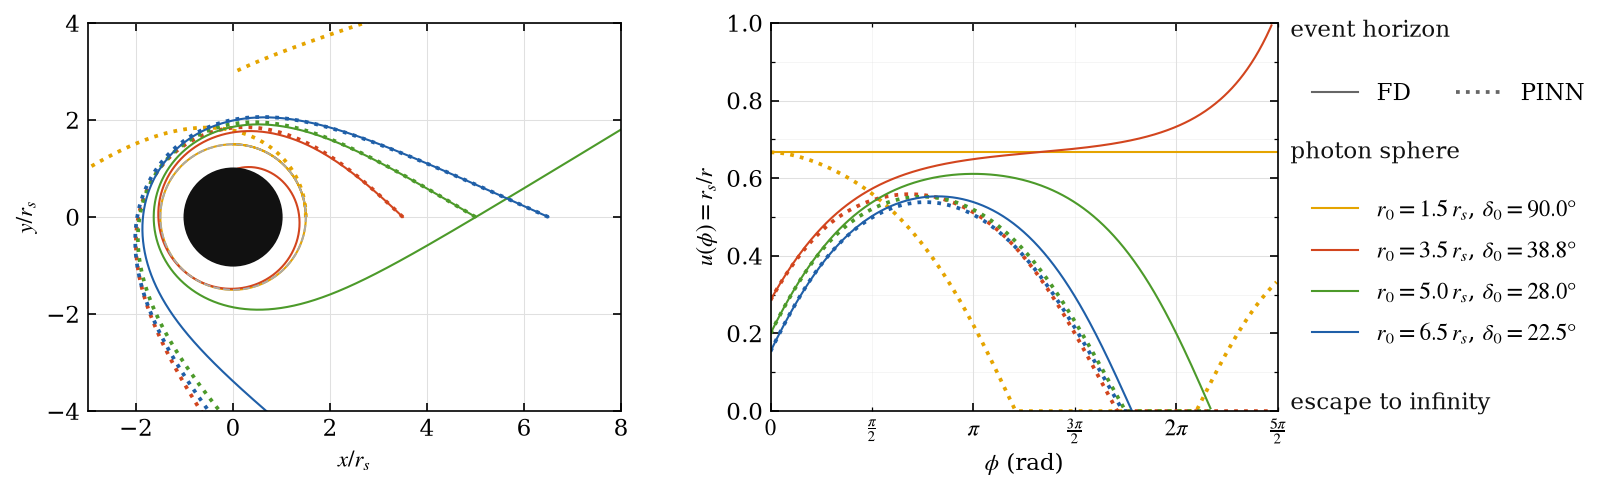

Saved: figures/xy_uphi_fd_pinn_five_pi_by_2_no_slicing_demo.pdf


In [12]:
# Overlay FD + PINN, Δφ = φmax (no slicing)
pinn_data = run_pinn_comparison(DEMO_ORBITS, fd_data_demo, dphi=phi_max, phi_max=phi_max,
                    orbit_label='demo', save=True)

#### ↳ Figure 3: Domain Slicing Strategy
Illustration of the slicing strategy: three orbits (FD solver) shown
over the full φ range, with three overlaid on side panels within one
φ-slice.

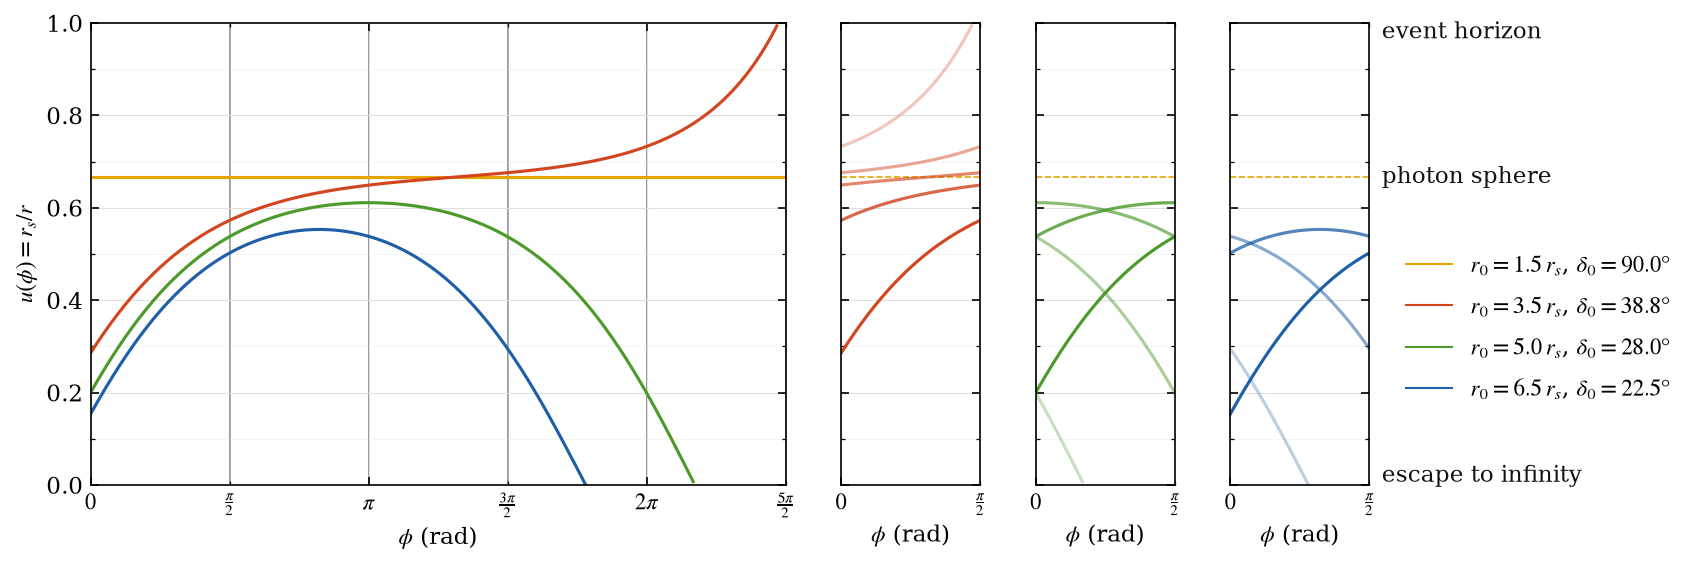

Saved: figures/uphi_segment_panels_pi-over-2.pdf


In [13]:
# Removing the photon sphere (irrelevant for the illustration)
orbits_panels = [orb for orb in DEMO_ORBITS if orb['delta'] != 90][:3]

# Overlaying FD orbit segments of width [0 pi/2]
plot_uphi_with_segment_panels(DEMO_ORBITS, orbits_panels, np.pi/2, phi_max,
                              name='uphi_segment_panels_pi-over-2', save=True)

### Section 4: Results

#### ↳ Figure 4: FD + PINN comparison, Δφ = 0.1
Solutions of PINN-Slicer, trained and recursively deployed over the
φ-slice [0, Δφ], Δφ = 0.1, closely matching the finite-difference (FD)
reference.


Loading PINN model from parameter file: pinn4bhoc/runs/dphi010/dphi010_params.pth



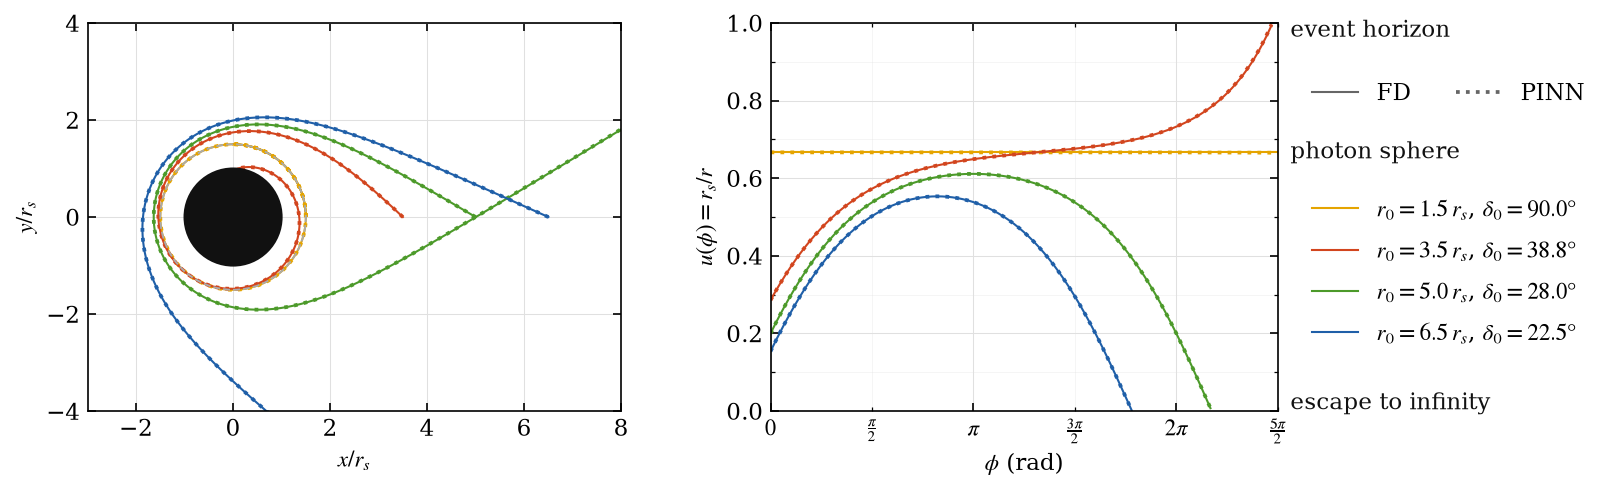

Saved: figures/xy_uphi_fd_pinn_dphi010_demo.pdf


In [14]:
# Overlay FD + PINN, Δφ = 0.1
pinn_data = run_pinn_comparison(DEMO_ORBITS, fd_data_demo, dphi=0.1, phi_max=phi_max,
                    orbit_label='demo', save=True)

#### ↳ Table 1: RMSE & Solution Domain

In [16]:
print_result_table(DEMO_ORBITS, fd_data_demo, pinn_data)


            r0     delta        u0        v0     rmse_u     rmse_v   phi_reached   type                
-----------------------------------------------------------------------------------------------
   0      1.50   90.0000    0.6667      0.00   2.44e-04   2.45e-04         7.854   photon sphere       
   1      3.50   38.8200    0.2857      0.30   4.94e-04   5.96e-04         7.756   still orbiting      
   2      5.00   27.9937    0.2000      0.34   1.06e-04   5.61e-05         6.811   escaping to outer space
   3      6.50   22.5000    0.1538      0.34   2.07e-05   1.76e-05         5.590   escaping to outer space


### Appendices

### Appendix B: PINN Failure with Boomerang Orbits

#### ↳ Figure 6: FD + PINN, boomerang orbits


Loading PINN model from parameter file: pinn4bhoc/runs/five_pi_by_2/pinn_params.pth



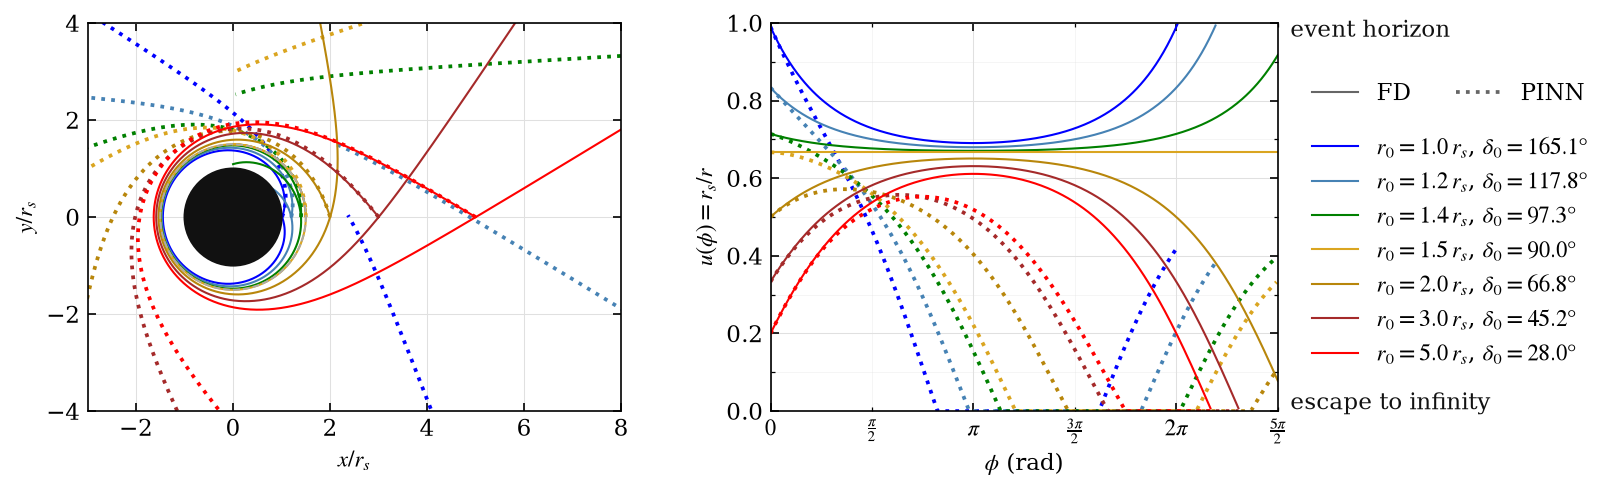

Saved: figures/xy_uphi_fd_pinn_five_pi_by_2_no_slicing_boomerang.pdf


In [18]:
# Get reference solutions with boomerang orbits
fd_data_boomerang = {}
for orb in BOOMERANG_ORBITS:
    u_fd, v_fd, phi_fd = fd_solver((orb['u0'], orb['v0']), phi)
    fd_data_boomerang[(orb['r0'], orb['delta'])] = (phi_fd, u_fd, v_fd)

# FD + PINN solution,  Δφ = φmax (no slicing) with boomerang orbits
pinn_data = run_pinn_comparison(BOOMERANG_ORBITS, fd_data_boomerang,
                                dphi=phi_max,
                                phi_max=phi_max,
                                orbit_label='boomerang',
                                legend_anchor=(1.05, 0.73),
                                save=True)

### Appendix C: Validation loss across training segments

#### ↳ Figure 7: Final average loss vs Δφ
Final average validation loss as a function of the training segment width ∆ϕ.

Training was run separately (not reproduced in this notebook)

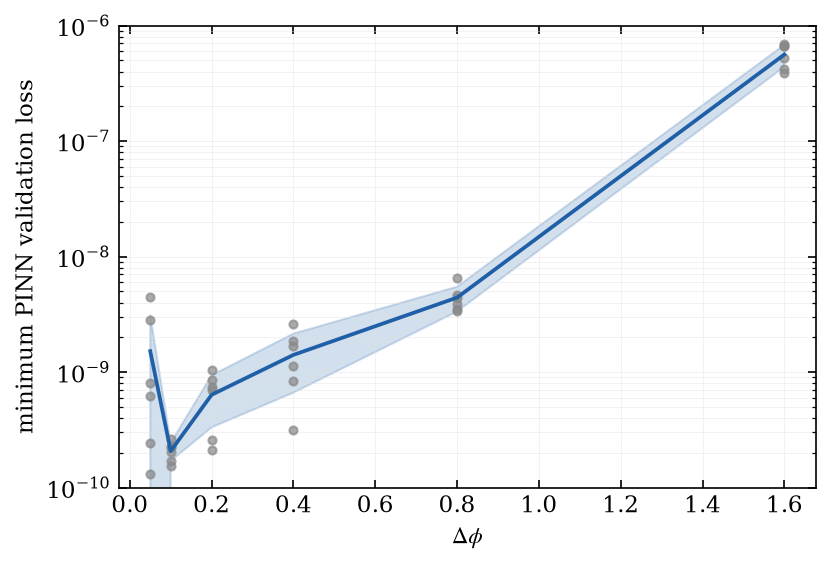

Saved: figures/loss_vs_dphi.pdf


In [19]:
LOSS_VS_DPHI_RAW = {
    0.05: [1.305102e-10, 2.819534e-09, 6.222114e-10, 7.979259e-10, 2.447076e-10, 4.480317e-09],
    0.10: [1.706340e-10, 2.030031e-10, 2.653919e-10, 2.258125e-10, 1.526566e-10, 2.236567e-10],
    0.20: [2.102204e-10, 2.576394e-10, 7.423668e-10, 8.614548e-10, 7.016583e-10, 1.039313e-09],
    0.40: [1.685030e-09, 8.427916e-10, 1.127251e-09, 2.612233e-09, 3.135684e-10, 1.864791e-09],
    0.80: [3.396353e-09, 3.910152e-09, 6.584242e-09, 4.690594e-09, 3.509198e-09, 4.379387e-09],
    1.60: [6.66828e-07, 4.242561e-07, 6.663738e-07, 6.936327e-07, 3.896478e-07, 5.240802e-07],
}

plot_loss_vs_dphi(LOSS_VS_DPHI_RAW, name='loss_vs_dphi', save=True)

### Appendix D: More FD + PINN comparisons

#### ↳ Figure 8: FD and PINN-Slicer solutions for ∆ϕ = 0.05



Loading PINN model from parameter file: pinn4bhoc/runs/dphi005/dphi005_params.pth



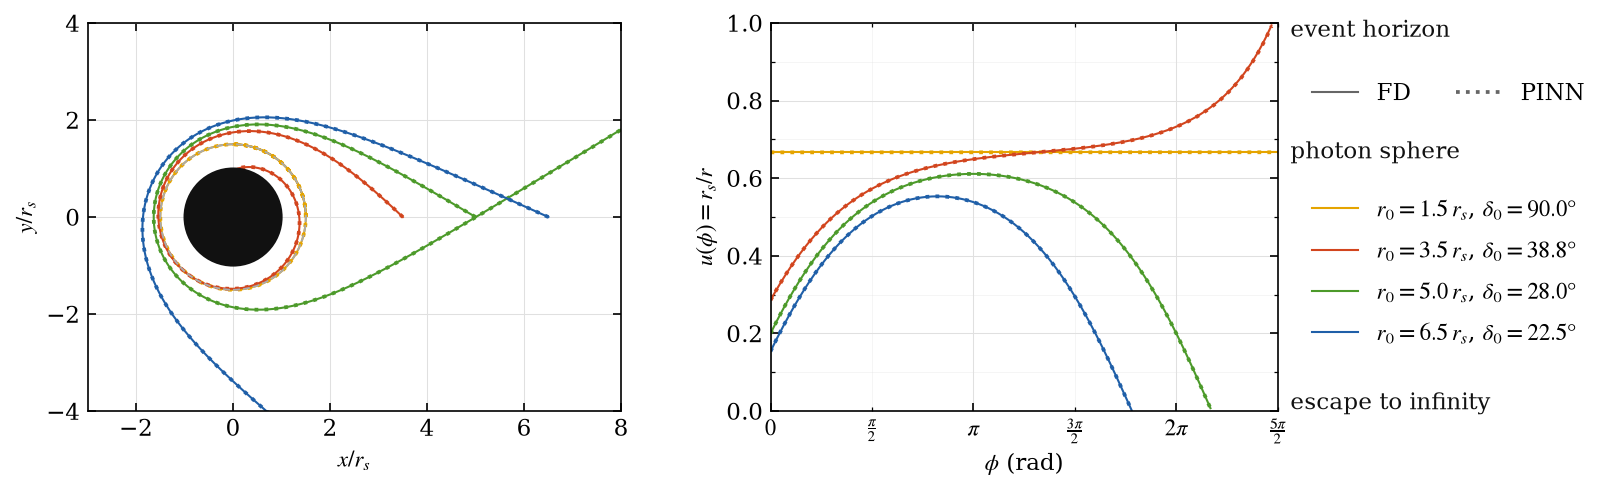

Saved: figures/xy_uphi_fd_pinn_dphi005_demo.pdf


In [20]:
pinn_data = run_pinn_comparison(DEMO_ORBITS, fd_data_demo, dphi=0.05, phi_max=phi_max,
                    orbit_label='demo', save=True)

#### ↳ Figure 9: FD and PINN-Slicer solutions for ∆ϕ = 0.20



Loading PINN model from parameter file: pinn4bhoc/runs/dphi020/dphi020_params.pth



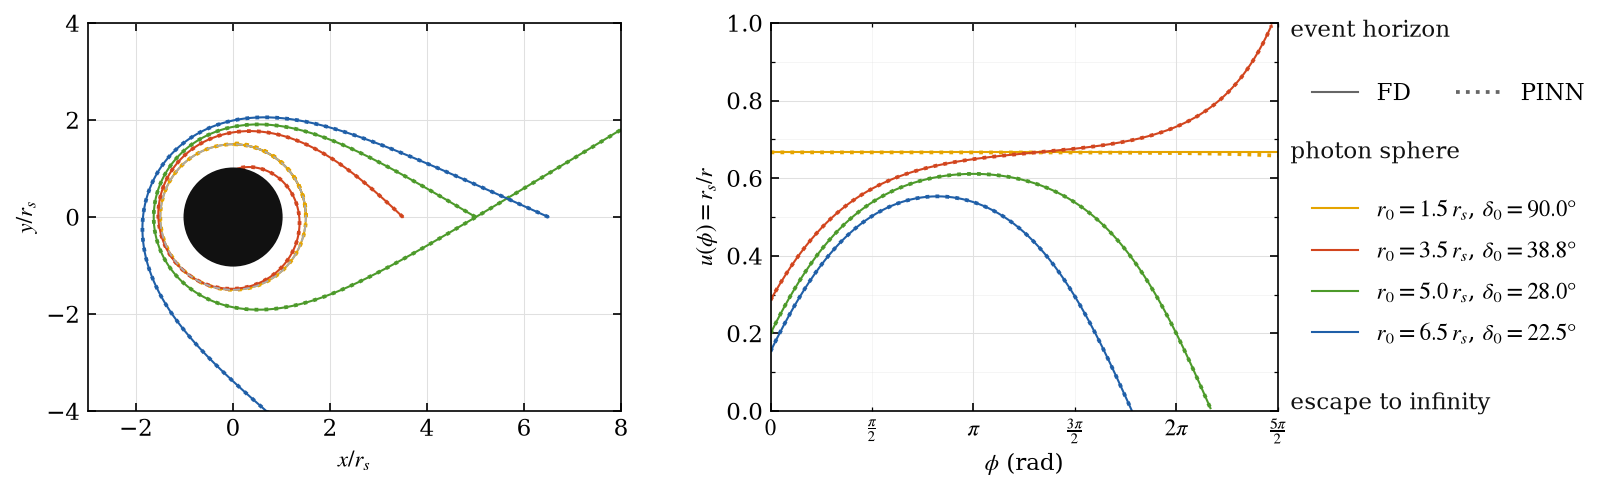

Saved: figures/xy_uphi_fd_pinn_dphi020_demo.pdf


In [21]:
pinn_data = run_pinn_comparison(DEMO_ORBITS, fd_data_demo, dphi=0.20, phi_max=phi_max,
                    orbit_label='demo', save=True)

#### ↳ Figure 10: FD and PINN-Slicer solutions for ∆ϕ = 0.40




Loading PINN model from parameter file: pinn4bhoc/runs/dphi040/dphi040_params.pth



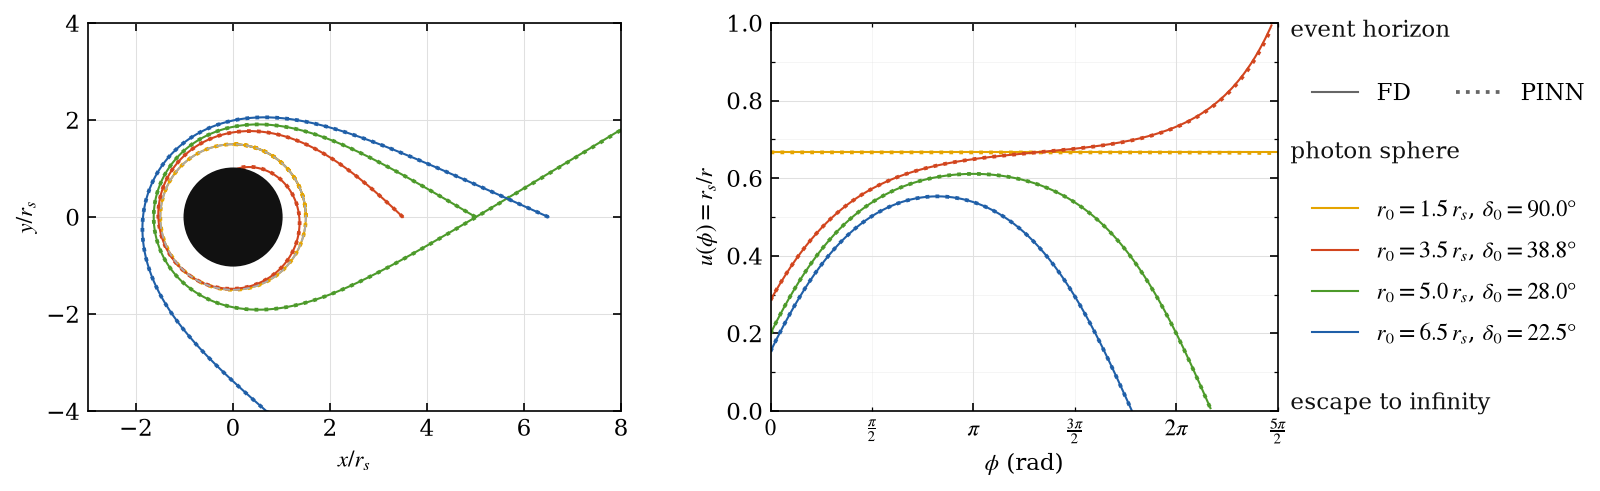

Saved: figures/xy_uphi_fd_pinn_dphi040_demo.pdf


In [22]:
pinn_data = run_pinn_comparison(DEMO_ORBITS, fd_data_demo, dphi=0.40, phi_max=phi_max,
                    orbit_label='demo', save=True)

#### ↳ Figure 11: FD and PINN-Slicer solutions for ∆ϕ = 0.8


Loading PINN model from parameter file: pinn4bhoc/runs/dphi080/dphi080_params.pth



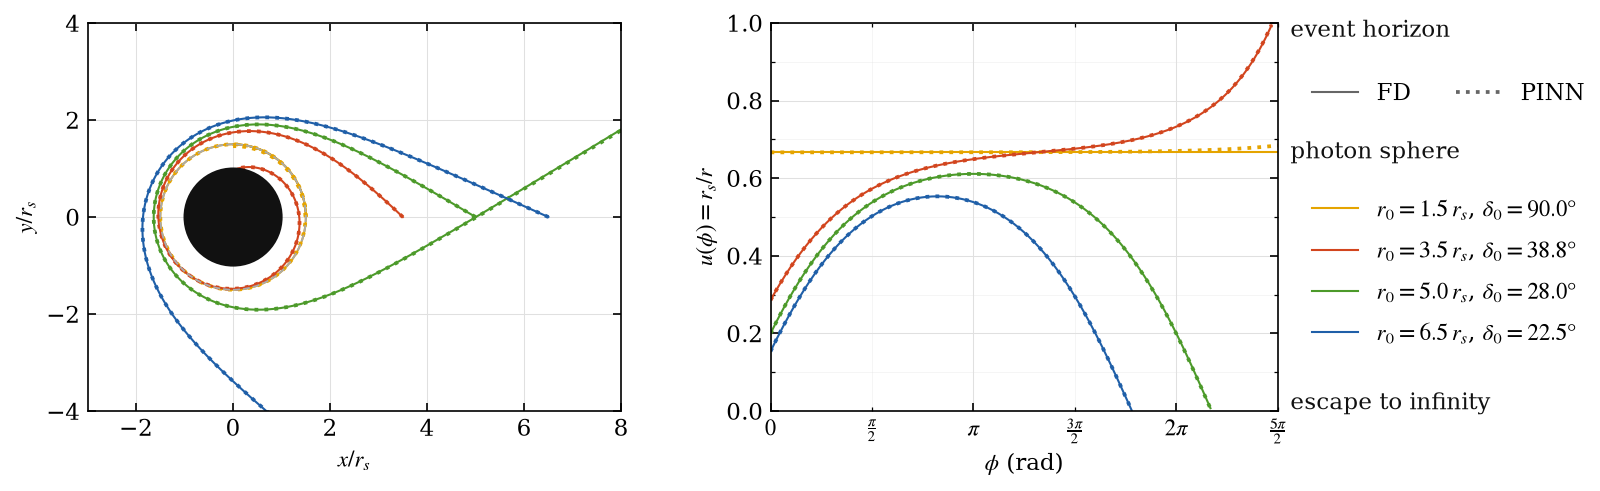

Saved: figures/xy_uphi_fd_pinn_dphi080_demo.pdf


In [23]:
pinn_data = run_pinn_comparison(DEMO_ORBITS, fd_data_demo, dphi=0.80, phi_max=phi_max,
                    orbit_label='demo', save=True)

#### ↳ Figure 12: FD and PINN-Slicer solutions for ∆ϕ = 1.6


Loading PINN model from parameter file: pinn4bhoc/runs/dphi160/dphi160_params.pth



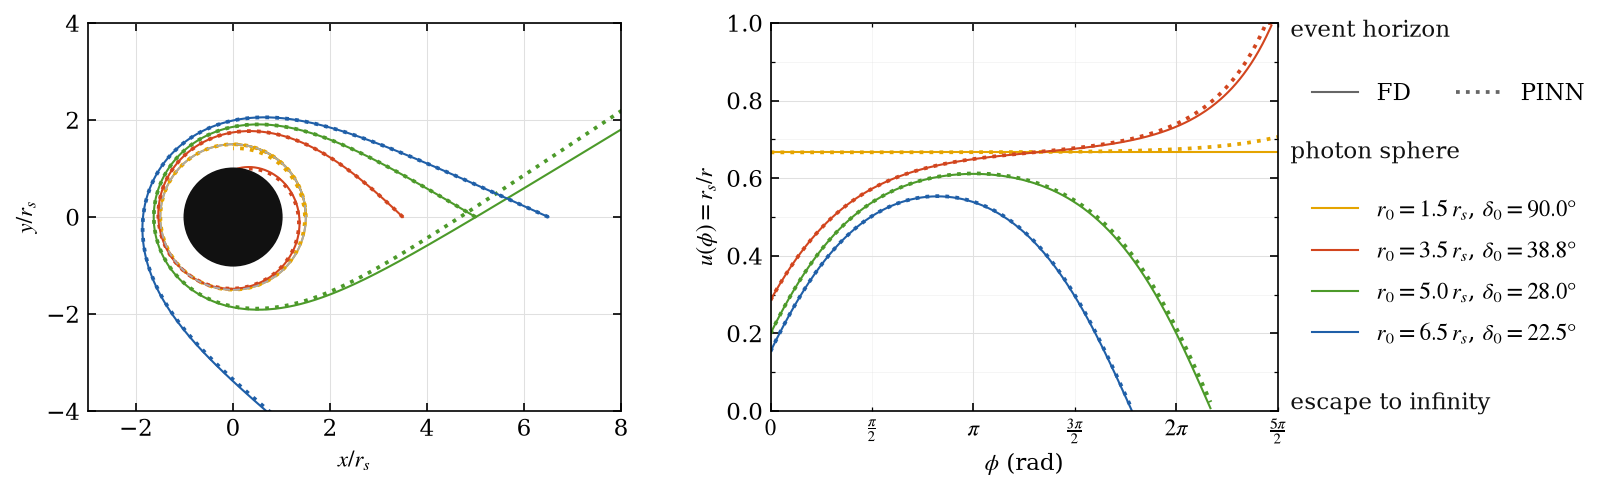

Saved: figures/xy_uphi_fd_pinn_dphi160_demo.pdf


In [24]:
pinn_data = run_pinn_comparison(DEMO_ORBITS, fd_data_demo, dphi=1.6, phi_max=phi_max,
                    orbit_label='demo', save=True)

## Copy to Drive

In [25]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [27]:
!cp -r figures /content/gdrive/MyDrive/Research/ML4PS2026/pinn_plots/